In [1]:
import numpy as np
import neuroboros as nb
from scipy.spatial.distance import pdist
from scipy.stats import pearsonr, zscore
import matplotlib.pyplot as plt
import neuroboros as nb
import pickle
import math
from glob import glob
import seaborn as sns

/dartfs-hpc/rc/home/q/f007d9q/neuroboros/src/neuroboros/io.py:56: UserWarning: DataLad dataset core exists at /dartfs-hpc/rc/home/q/f007d9q/.neuroboros-data/core, but does not have source https://gin.g-node.org/neuroboros/core as a sibling.
  warnings.warn(


In [ ]:
with open("Figure Supplement 6-Source Data 4.pkl", "rb") as f:
    sids = pickle.load(f)

In [ ]:
num_list = sids['bang']
exclude_list = ['CC220519', 'CC610462', 'CC710518']
age_dict = dict()
with open("Figure Supplement 6-Source Data 3.pkl", 'rb') as file:
    loaded_dict = pickle.load(file)
age_group = dict()
for i in range(11):
    age_group[i] = []
bang_data = sids['bang']
for index, row in loaded_dict.iterrows():
    if index not in bang_data:
        continue
    if index in exclude_list:
        continue
    age_group[int(math.floor(row['Age']/10.0))].append(index)
    age_dict[index] = row['Age']
    if(row['Age']>=110.0):
        age_group[10].append(index)

In [ ]:
with open("Figure Supplement 6-Source Data 1.pkl", "rb") as f:
    corr_all = pickle.load(f)

In [33]:
my_dict = corr_all
transposed_lists = list(zip(*my_dict.values()))
max_values_sorted_indexes = sorted(range(len(transposed_lists)), key=lambda i: max(transposed_lists[i]), reverse=True)
sorted_dict = {key: [my_dict[key][i] for i in max_values_sorted_indexes] for key in my_dict}
print("Sorted dictionary:")
for key in sorted_dict:
    print(f"{key}: {sorted_dict[key]}")

Sorted dictionary:
young: [0.4098428983174915, 0.415538412148987, 0.4071967481948862, 0.38955049219448334, 0.38846809726389775, 0.3981480403268717, 0.37517557564850074, 0.38101981168332066, 0.395739444997662, 0.3824253186421331, 0.3715488442079115, 0.37516303563818176, 0.3836959754661685, 0.3719005639146543, 0.37806120316112873, 0.36560026968320597, 0.33626397861352286, 0.3585091494675487, 0.3671895069137724, 0.367807020611928, 0.3572309297700215, 0.36895330416238126, 0.3631821433328367, 0.3679470498670149, 0.3443566203898015, 0.3489607290917868, 0.35914629521310504, 0.3351175255488987, 0.3344235538623405, 0.35038862677885513, 0.3278164812362139, 0.3285486216116674, 0.33297669920085765, 0.332978382385485, 0.3274904954028505, 0.33530631268337563, 0.3177286114668135, 0.316806373126704, 0.3050937065039281, 0.3193563405741223, 0.32843344144076814, 0.30335848065982124, 0.3044148687187408, 0.2944007591772403, 0.3164114467545293, 0.30363410564285176, 0.2963234161275484, 0.2998566054890696, 0.

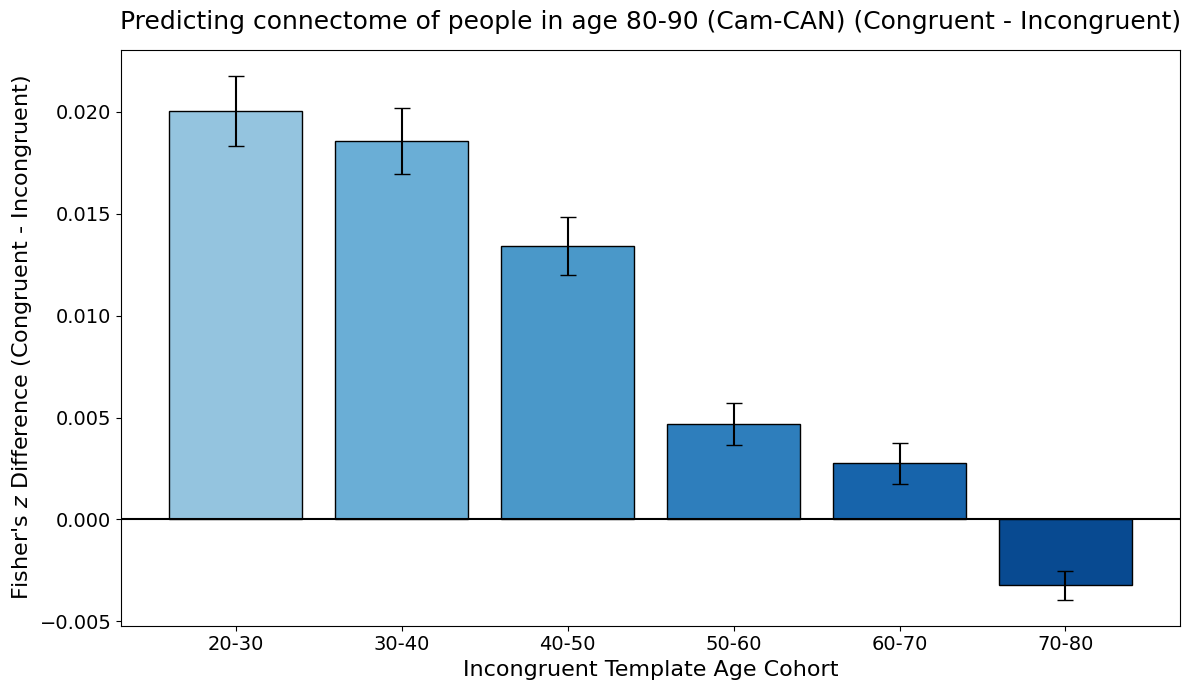

In [34]:
import numpy as np
import matplotlib.pyplot as plt
congruent_key = 'old'
incongruent_keys = ['young', '30-40', '40-50', '50-60', '60-70', '70-80']
x_labels = ['20-30', '30-40', '40-50', '50-60', '60-70', '70-80']
r_congruent = np.array(corr_all[congruent_key])
z_congruent = np.arctanh(r_congruent) 
mean_z_diffs = []
sem_z_diffs = []
for key in incongruent_keys:
    r_incongruent = np.array(corr_all[key])
    z_incongruent = np.arctanh(r_incongruent)
    z_diff = z_congruent - z_incongruent
    mean_z_diffs.append(np.mean(z_diff))
    sem_z_diffs.append(np.std(z_diff, ddof=1) / np.sqrt(len(z_diff)))
plt.figure(figsize=(12, 7))
x_pos = np.arange(len(incongruent_keys))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(incongruent_keys)))
plt.bar(x_pos, mean_z_diffs, yerr=sem_z_diffs, capsize=6, color=colors, edgecolor='black')
plt.axhline(0, color='black', linewidth=1.5) # Thicker baseline at 0
plt.xticks(x_pos, x_labels, fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel("Incongruent Template Age Cohort", fontsize=16)
plt.ylabel(r"Fisher's $z$ Difference (Congruent - Incongruent)", fontsize=16)
plt.title("Predicting connectome of people in age 80-90 (Cam-CAN) (Congruent - Incongruent)", fontsize=18, pad=15)
plt.tight_layout()
plt.show()

In [22]:
with open("Figure Supplement 6-Source Data 2.pkl", "rb") as f:
    corr_all = pickle.load(f)

In [23]:
my_dict = corr_all
transposed_lists = list(zip(*my_dict.values()))
max_values_sorted_indexes = sorted(range(len(transposed_lists)), key=lambda i: max(transposed_lists[i]), reverse=True)
sorted_dict = {key: [my_dict[key][i] for i in max_values_sorted_indexes] for key in my_dict}
print("Sorted dictionary:")
for key in sorted_dict:
    print(f"{key}: {sorted_dict[key]}")

Sorted dictionary:
young: [0.5682404373899298, 0.5619984580615145, 0.5573268483533201, 0.5462800634741618, 0.5446600015317594, 0.5424475965343362, 0.5406232627100629, 0.5341457857473425, 0.5277680414540227, 0.5220394640255202, 0.5234437096063846, 0.5235305530832517, 0.5243475786446032, 0.5181495073856051, 0.518729413159787, 0.5170898753187223, 0.5160877329360131, 0.509812758275443, 0.5122465759827232, 0.507655499316606, 0.5067841166578116, 0.5098118393753549, 0.5101012409743839, 0.5081390920412604, 0.5092472223161854, 0.4950046054306352, 0.49812472835018934, 0.496575311243572, 0.4937306549265319, 0.4941135350203691, 0.48970747493544187, 0.48590302191879964, 0.4899728235845842, 0.48181665891271497, 0.4851396899794855, 0.48293315894317224, 0.48655334979067455, 0.48027195668160627, 0.4862413987135854, 0.48510476581855183, 0.4782873691565897, 0.4791515188976883, 0.4816648759062799, 0.4781391831217257, 0.47679283211852147, 0.47443769212945186, 0.47069183162032935, 0.47233265561279625, 0.460

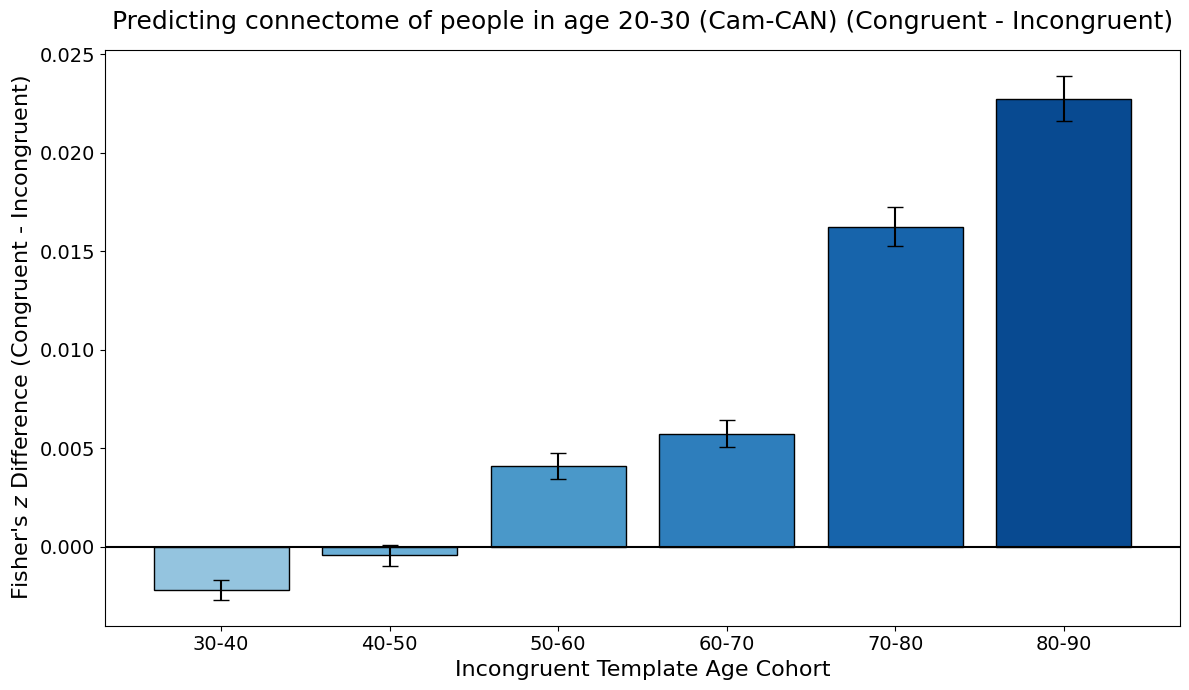

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# ... [Keep your existing data loading loop up to: my_dict = corr_all] ...

# 1. Define the congruent template for this young participant group
congruent_key = 'young'

# Define the incongruent templates and their corresponding labels for the x-axis
# Ordered from closest in age to furthest in age
incongruent_keys = ['30-40', '40-50', '50-60', '60-70', '70-80', 'old']
x_labels = ['30-40', '40-50', '50-60', '60-70', '70-80', '80-90']

# 2. Extract congruent correlations and apply Fisher's z-transformation
r_congruent = np.array(corr_all[congruent_key])
z_congruent = np.arctanh(r_congruent) 

mean_z_diffs = []
sem_z_diffs = []

# 3. Calculate the z-difference for each incongruent template
for key in incongruent_keys:
    r_incongruent = np.array(corr_all[key])
    z_incongruent = np.arctanh(r_incongruent)
    
    # Calculate pairwise difference for each participant
    z_diff = z_congruent - z_incongruent
    
    # Calculate mean and Standard Error of the Mean (SEM) for error bars
    mean_z_diffs.append(np.mean(z_diff))
    sem_z_diffs.append(np.std(z_diff, ddof=1) / np.sqrt(len(z_diff)))

# 4. Plotting the Bar Chart
plt.figure(figsize=(12, 7)) # Made slightly larger to fit bigger fonts
x_pos = np.arange(len(incongruent_keys))

# Create a color gradient (you can reverse the linspace if you want the colors to go light-to-dark)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(incongruent_keys)))

# Plot bars with error bars (capsize increased to 6 for better visibility)
plt.bar(x_pos, mean_z_diffs, yerr=sem_z_diffs, capsize=6, color=colors, edgecolor='black')

# Formatting with LARGER FONTS
plt.axhline(0, color='black', linewidth=1.5) # Thicker baseline at 0

# Adjust tick mark sizes
plt.xticks(x_pos, x_labels, fontsize=14)
plt.yticks(fontsize=14)

# Adjust axis label sizes
plt.xlabel("Incongruent Template Age Cohort", fontsize=16)
plt.ylabel(r"Fisher's $z$ Difference (Congruent - Incongruent)", fontsize=16)

# Adjust title size and add padding
plt.title("Predicting connectome of people in age 20-30 (Cam-CAN) (Congruent - Incongruent)", fontsize=18, pad=15)

plt.tight_layout()
plt.show()